Saved: digits_performance.png
Saved: breast_cancer_performance.png
Saved: wine_performance.png


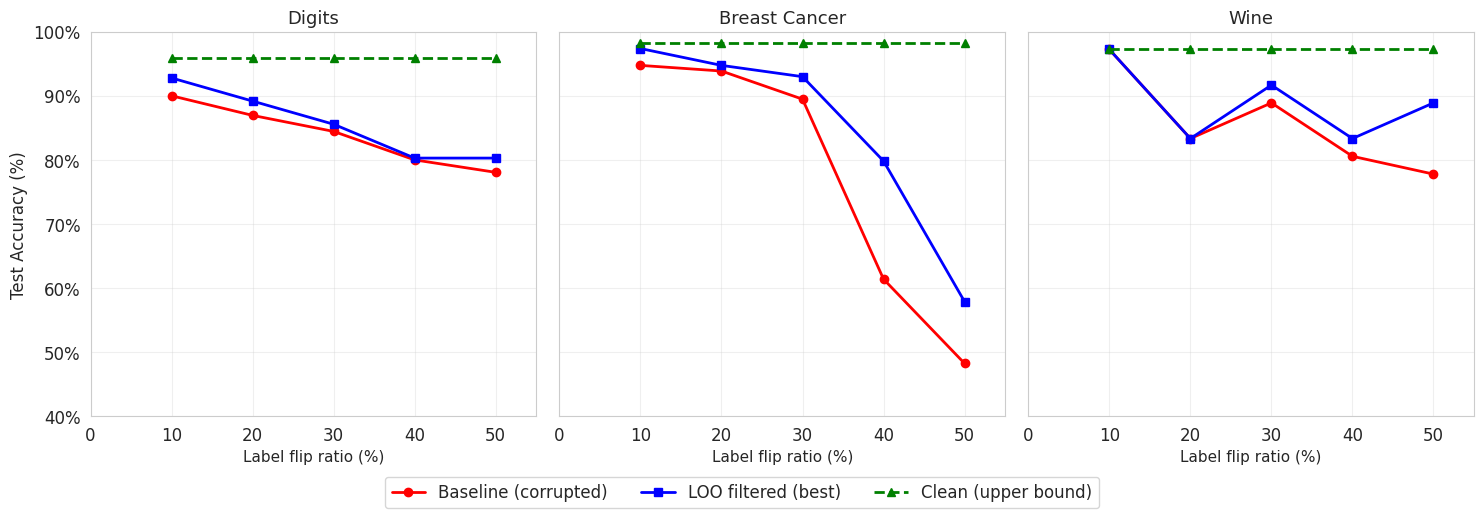

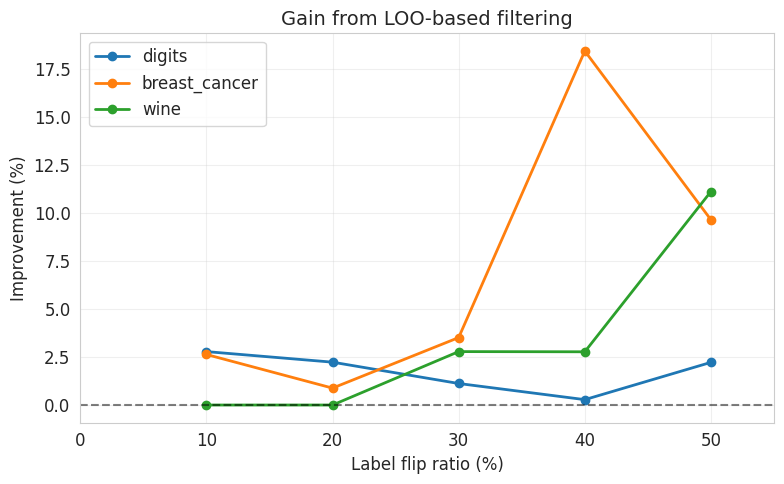

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Data from your global summary (as decimals, will multiply by 100 for percentage plots)
data = {
    "dataset": ["digits", "breast_cancer", "wine", 
                "digits", "breast_cancer", "wine",
                "digits", "breast_cancer", "wine",
                "digits", "breast_cancer", "wine",
                "digits", "breast_cancer", "wine"],
    "corrupt_ratio": [0.1, 0.1, 0.1,
                      0.2, 0.2, 0.2,
                      0.3, 0.3, 0.3,
                      0.4, 0.4, 0.4,
                      0.5, 0.5, 0.5],
    "baseline_test": [0.9000, 0.9474, 0.9722,
                      0.8694, 0.9386, 0.8333,
                      0.8444, 0.8947, 0.8889,
                      0.8000, 0.6140, 0.8056,
                      0.7806, 0.4825, 0.7778],
    "clean_test": [0.9583, 0.9825, 0.9722,
                   0.9583, 0.9825, 0.9722,
                   0.9583, 0.9825, 0.9722,
                   0.9583, 0.9825, 0.9722,
                   0.9583, 0.9825, 0.9722],
    "best_loo_test": [0.9278, 0.9737, 0.9722,
                      0.8917, 0.9474, 0.8333,
                      0.8556, 0.9298, 0.9167,
                      0.8028, 0.7982, 0.8333,
                      0.8028, 0.5789, 0.8889]
}

df = pd.DataFrame(data)
df["corrupt_percent"] = df["corrupt_ratio"] * 100

# Convert all accuracy values to percentages
df["baseline_test"] = df["baseline_test"] * 100
df["clean_test"] = df["clean_test"] * 100
df["best_loo_test"] = df["best_loo_test"] * 100

sns.set_style("whitegrid")
plt.rcParams["font.size"] = 12

# --- Save individual plots per dataset with y-axis in % ---
datasets = df["dataset"].unique()
for ds in datasets:
    plt.figure(figsize=(7, 5))
    subset = df[df["dataset"] == ds]
    
    plt.plot(subset["corrupt_percent"], subset["baseline_test"], 
             'o-', color='red', linewidth=2, label="Baseline (corrupted)")
    plt.plot(subset["corrupt_percent"], subset["best_loo_test"], 
             's-', color='blue', linewidth=2, label="LOO filtered (best)")
    plt.plot(subset["corrupt_percent"], subset["clean_test"], 
             '^--', color='green', linewidth=2, label="Clean (upper bound)")
    
    plt.xlabel("Label flip ratio (%)", fontsize=12)
    plt.ylabel("Test Accuracy (%)", fontsize=12)
    plt.title(ds.replace("_", " ").title(), fontsize=14)
    plt.xlim(0, 55)
    plt.ylim(40, 100)   # from 40% to 100%
    plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best')
    plt.tight_layout()
    
    filename = f"{ds}_performance.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: {filename}")

# --- Combined subplot figure (with percentage y-axis) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, ds in zip(axes, datasets):
    subset = df[df["dataset"] == ds]
    ax.plot(subset["corrupt_percent"], subset["baseline_test"], 
            'o-', color='red', linewidth=2, label="Baseline (corrupted)")
    ax.plot(subset["corrupt_percent"], subset["best_loo_test"], 
            's-', color='blue', linewidth=2, label="LOO filtered (best)")
    ax.plot(subset["corrupt_percent"], subset["clean_test"], 
            '^--', color='green', linewidth=2, label="Clean (upper bound)")
    ax.set_xlabel("Label flip ratio (%)", fontsize=11)
    ax.set_title(ds.replace("_", " ").title(), fontsize=13)
    ax.set_xlim(0, 55)
    ax.set_ylim(40, 100)
    ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
    ax.grid(True, alpha=0.3)
    if ax == axes[0]:
        ax.set_ylabel("Test Accuracy (%)", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12, 
           bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig("global_performance.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Improvement plot (still in percentage points, not percent) ---
# Improvement remains as raw difference (percentage points)
plt.figure(figsize=(8, 5))
for ds in datasets:
    subset = df[df["dataset"] == ds]
    # improvement already in percentage points because we multiplied by 100
    improvement = subset["best_loo_test"] - subset["baseline_test"]
    plt.plot(subset["corrupt_percent"], improvement, 'o-', label=ds, linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Label flip ratio (%)", fontsize=12)
plt.ylabel("Improvement (%)", fontsize=12)
plt.title("Gain from LOO‑based filtering", fontsize=14)
plt.xlim(0, 55)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("improvement_per_dataset.png", dpi=300, bbox_inches="tight")
plt.show()

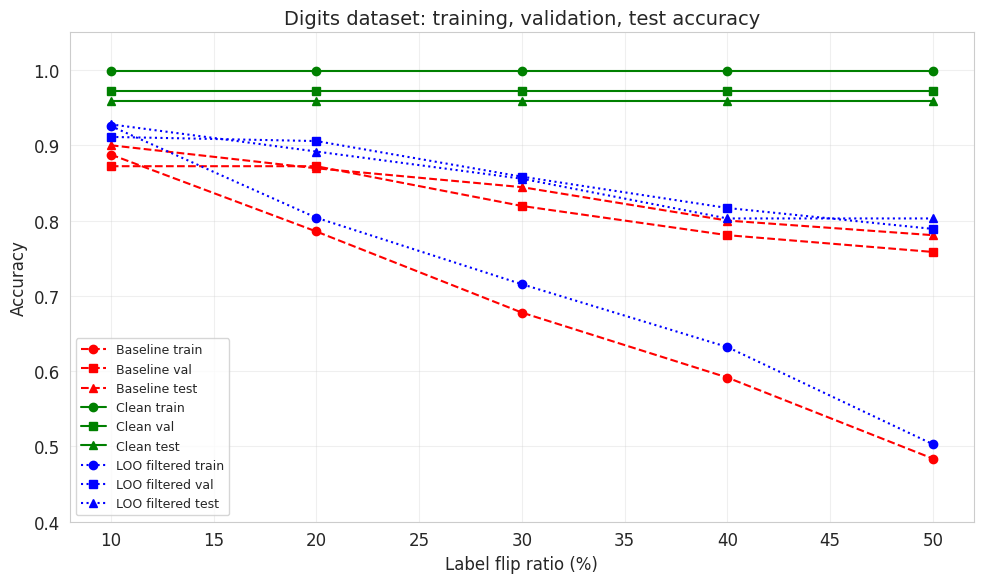

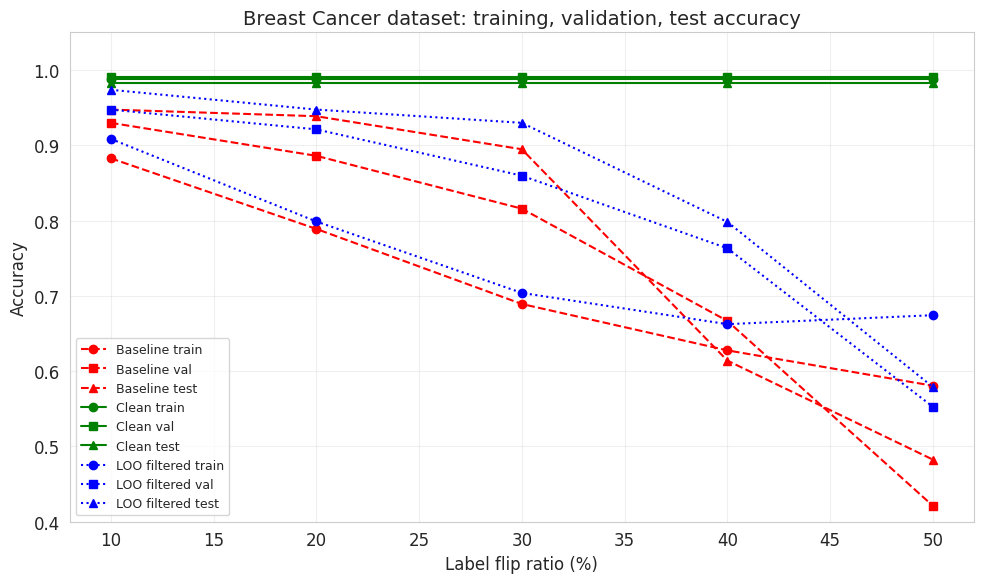

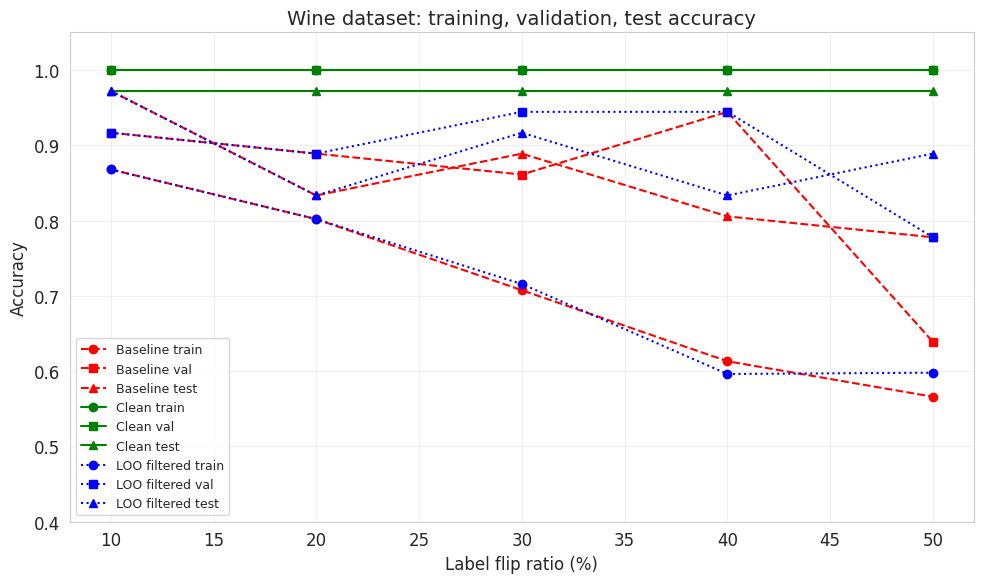

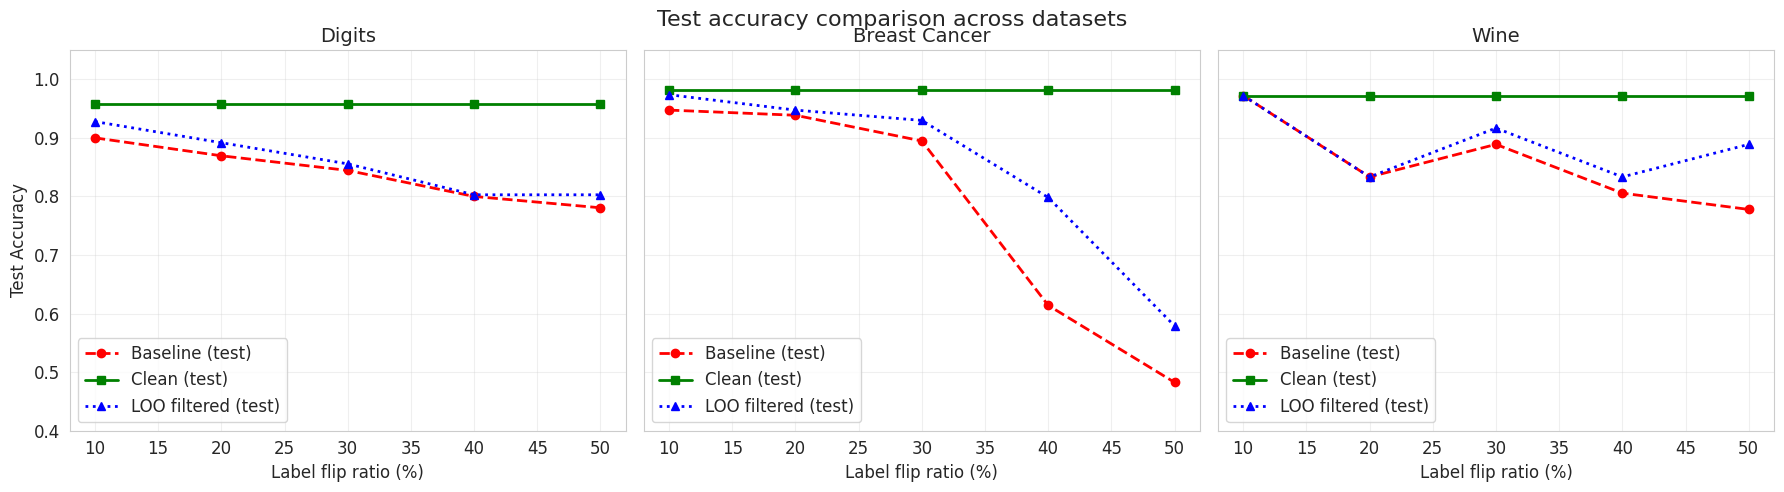

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from the log (baseline, clean, best LOO removal)
# For each dataset and corruption ratio (10,20,30,40,50)
# Format: (corrupt_ratio, baseline_train, baseline_val, baseline_test,
#           clean_train, clean_val, clean_test,
#           loo_train, loo_val, loo_test)

digits_data = [
    (10, 0.8877, 0.8722, 0.9000, 0.9991, 0.9722, 0.9583, 0.9256, 0.9111, 0.9278),
    (20, 0.7855, 0.8722, 0.8694, 0.9991, 0.9722, 0.9583, 0.8038, 0.9056, 0.8917),
    (30, 0.6778, 0.8194, 0.8444, 0.9991, 0.9722, 0.9583, 0.7155, 0.8583, 0.8556),
    (40, 0.5915, 0.7806, 0.8000, 0.9991, 0.9722, 0.9583, 0.6320, 0.8167, 0.8028),
    (50, 0.4838, 0.7583, 0.7806, 0.9991, 0.9722, 0.9583, 0.5029, 0.7889, 0.8028)
]

breast_cancer_data = [
    (10, 0.8827, 0.9298, 0.9474, 0.9883, 0.9912, 0.9825, 0.9085, 0.9474, 0.9737),
    (20, 0.7889, 0.8860, 0.9386, 0.9883, 0.9912, 0.9825, 0.7988, 0.9211, 0.9474),
    (30, 0.6892, 0.8158, 0.8947, 0.9883, 0.9912, 0.9825, 0.7039, 0.8596, 0.9298),
    (40, 0.6276, 0.6667, 0.6140, 0.9883, 0.9912, 0.9825, 0.6624, 0.7632, 0.7982),
    (50, 0.5806, 0.4211, 0.4825, 0.9883, 0.9912, 0.9825, 0.6743, 0.5526, 0.5789)
]

wine_data = [
    (10, 0.8679, 0.9167, 0.9722, 1.0000, 1.0000, 0.9722, 0.8679, 0.9167, 0.9722),
    (20, 0.8019, 0.8889, 0.8333, 1.0000, 1.0000, 0.9722, 0.8019, 0.8889, 0.8333),
    (30, 0.7075, 0.8611, 0.8889, 1.0000, 1.0000, 0.9722, 0.7157, 0.9444, 0.9167),
    (40, 0.6132, 0.9444, 0.8056, 1.0000, 1.0000, 0.9722, 0.5962, 0.9444, 0.8333),
    (50, 0.5660, 0.6389, 0.7778, 1.0000, 1.0000, 0.9722, 0.5979, 0.7778, 0.8889)
]

# Helper function to plot one dataset
def plot_dataset(name, data, color_baseline='red', color_clean='green', color_loo='blue'):
    ratios = [d[0] for d in data]
    baseline_train = [d[1] for d in data]
    baseline_val   = [d[2] for d in data]
    baseline_test  = [d[3] for d in data]
    clean_train    = [d[4] for d in data]
    clean_val      = [d[5] for d in data]
    clean_test     = [d[6] for d in data]
    loo_train      = [d[7] for d in data]
    loo_val        = [d[8] for d in data]
    loo_test       = [d[9] for d in data]
    
    plt.figure(figsize=(10, 6))
    # Baseline (dashed lines)
    plt.plot(ratios, baseline_train, 'o--', color=color_baseline, label='Baseline train')
    plt.plot(ratios, baseline_val,   's--', color=color_baseline, label='Baseline val')
    plt.plot(ratios, baseline_test,  '^--', color=color_baseline, label='Baseline test')
    # Clean (solid lines)
    plt.plot(ratios, clean_train, 'o-', color=color_clean, label='Clean train')
    plt.plot(ratios, clean_val,   's-', color=color_clean, label='Clean val')
    plt.plot(ratios, clean_test,  '^-', color=color_clean, label='Clean test')
    # LOO best removal (dotted lines)
    plt.plot(ratios, loo_train, 'o:', color=color_loo, label='LOO filtered train')
    plt.plot(ratios, loo_val,   's:', color=color_loo, label='LOO filtered val')
    plt.plot(ratios, loo_test,  '^:', color=color_loo, label='LOO filtered test')
    
    plt.xlabel('Label flip ratio (%)', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(f'{name} dataset: training, validation, test accuracy', fontsize=14)
    plt.ylim(0.4, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{name.lower()}_train_val_test.png', dpi=300)
    plt.show()

# Generate plots for each dataset
plot_dataset('Digits', digits_data)
plot_dataset('Breast Cancer', breast_cancer_data)
plot_dataset('Wine', wine_data)

# Optional: Combined subplot figure (one row, three columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
datasets = [('Digits', digits_data), ('Breast Cancer', breast_cancer_data), ('Wine', wine_data)]
colors = {'baseline': 'red', 'clean': 'green', 'loo': 'blue'}

for ax, (name, data) in zip(axes, datasets):
    ratios = [d[0] for d in data]
    baseline_test = [d[3] for d in data]
    clean_test = [d[6] for d in data]
    loo_test = [d[9] for d in data]
    
    ax.plot(ratios, baseline_test, 'o--', color=colors['baseline'], linewidth=2, label='Baseline (test)')
    ax.plot(ratios, clean_test, 's-', color=colors['clean'], linewidth=2, label='Clean (test)')
    ax.plot(ratios, loo_test, '^:', color=colors['loo'], linewidth=2, label='LOO filtered (test)')
    ax.set_xlabel('Label flip ratio (%)', fontsize=12)
    ax.set_title(name, fontsize=14)
    ax.set_ylim(0.4, 1.05)
    ax.grid(True, alpha=0.3)
    if ax == axes[0]:
        ax.set_ylabel('Test Accuracy', fontsize=12)
    ax.legend(loc='best')

plt.suptitle('Test accuracy comparison across datasets', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig('combined_test_accuracy.png', dpi=600)
plt.show()

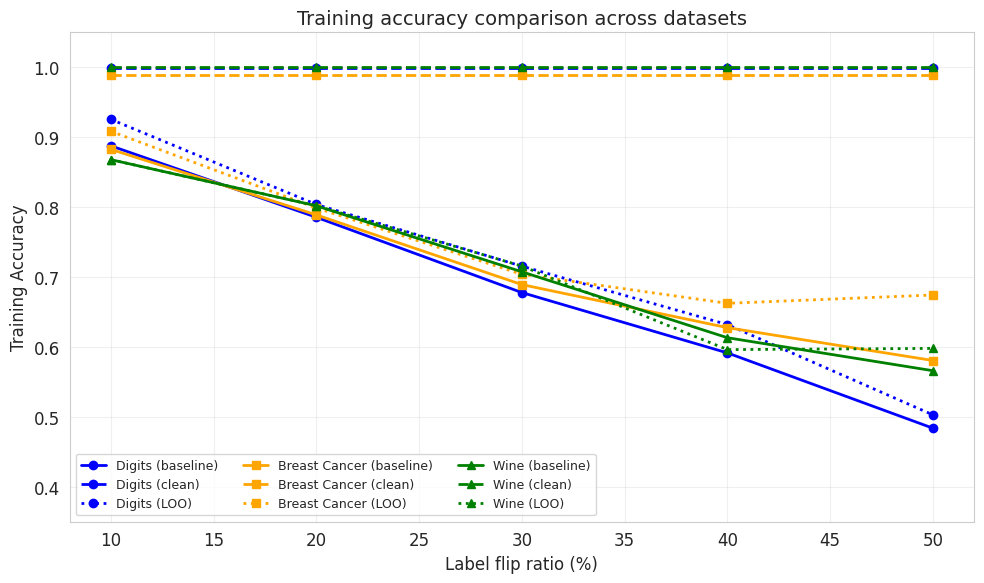

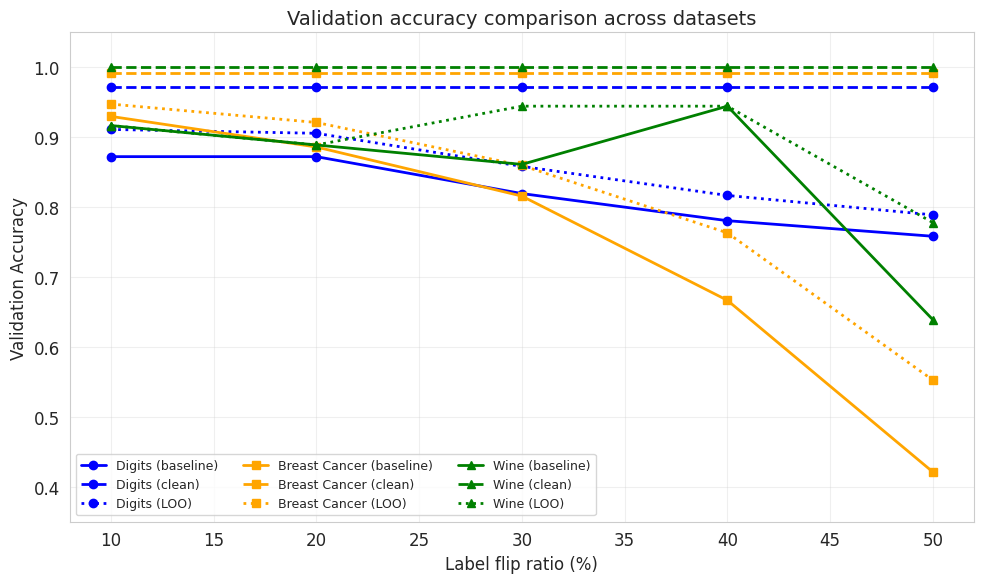

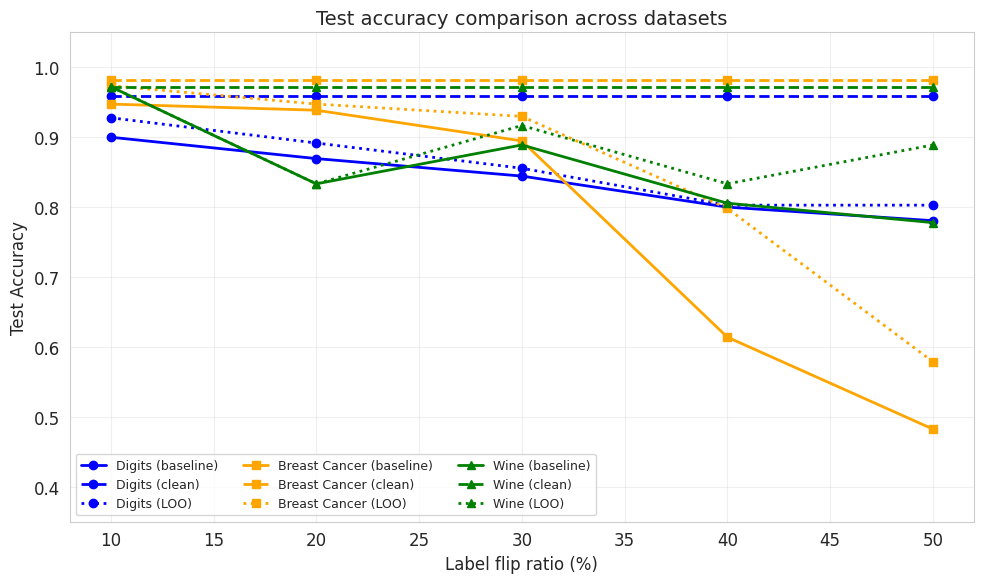

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from the log (baseline, clean, best LOO removal)
# For each dataset and corruption ratio (10,20,30,40,50)
# Format: (corrupt_ratio, baseline_train, baseline_val, baseline_test,
#           clean_train, clean_val, clean_test,
#           loo_train, loo_val, loo_test)

digits_data = [
    (10, 0.8877, 0.8722, 0.9000, 0.9991, 0.9722, 0.9583, 0.9256, 0.9111, 0.9278),
    (20, 0.7855, 0.8722, 0.8694, 0.9991, 0.9722, 0.9583, 0.8038, 0.9056, 0.8917),
    (30, 0.6778, 0.8194, 0.8444, 0.9991, 0.9722, 0.9583, 0.7155, 0.8583, 0.8556),
    (40, 0.5915, 0.7806, 0.8000, 0.9991, 0.9722, 0.9583, 0.6320, 0.8167, 0.8028),
    (50, 0.4838, 0.7583, 0.7806, 0.9991, 0.9722, 0.9583, 0.5029, 0.7889, 0.8028)
]

breast_cancer_data = [
    (10, 0.8827, 0.9298, 0.9474, 0.9883, 0.9912, 0.9825, 0.9085, 0.9474, 0.9737),
    (20, 0.7889, 0.8860, 0.9386, 0.9883, 0.9912, 0.9825, 0.7988, 0.9211, 0.9474),
    (30, 0.6892, 0.8158, 0.8947, 0.9883, 0.9912, 0.9825, 0.7039, 0.8596, 0.9298),
    (40, 0.6276, 0.6667, 0.6140, 0.9883, 0.9912, 0.9825, 0.6624, 0.7632, 0.7982),
    (50, 0.5806, 0.4211, 0.4825, 0.9883, 0.9912, 0.9825, 0.6743, 0.5526, 0.5789)
]

wine_data = [
    (10, 0.8679, 0.9167, 0.9722, 1.0000, 1.0000, 0.9722, 0.8679, 0.9167, 0.9722),
    (20, 0.8019, 0.8889, 0.8333, 1.0000, 1.0000, 0.9722, 0.8019, 0.8889, 0.8333),
    (30, 0.7075, 0.8611, 0.8889, 1.0000, 1.0000, 0.9722, 0.7157, 0.9444, 0.9167),
    (40, 0.6132, 0.9444, 0.8056, 1.0000, 1.0000, 0.9722, 0.5962, 0.9444, 0.8333),
    (50, 0.5660, 0.6389, 0.7778, 1.0000, 1.0000, 0.9722, 0.5979, 0.7778, 0.8889)
]

# Define colors and line styles for each dataset
dataset_styles = {
    'Digits': {'marker': 'o', 'linestyle': '-', 'color': 'blue'},
    'Breast Cancer': {'marker': 's', 'linestyle': '-', 'color': 'orange'},
    'Wine': {'marker': '^', 'linestyle': '-', 'color': 'green'}
}

# Function to plot a specific metric (train, val, or test)
def plot_metric(metric_name, idx_baseline, idx_clean, idx_loo):
    plt.figure(figsize=(10, 6))
    
    # Plot each dataset
    for name, data, style in zip(['Digits', 'Breast Cancer', 'Wine'],
                                 [digits_data, breast_cancer_data, wine_data],
                                 dataset_styles.values()):
        ratios = [d[0] for d in data]
        baseline = [d[idx_baseline] for d in data]
        clean = [d[idx_clean] for d in data]
        loo = [d[idx_loo] for d in data]
        
        # Baseline (solid line with dataset marker)
        plt.plot(ratios, baseline, marker=style['marker'], linestyle='-', 
                 color=style['color'], linewidth=2, 
                 label=f'{name} (baseline)')
        # Clean (dashed line)
        plt.plot(ratios, clean, marker=style['marker'], linestyle='--', 
                 color=style['color'], linewidth=2, 
                 label=f'{name} (clean)')
        # LOO (dotted line)
        plt.plot(ratios, loo, marker=style['marker'], linestyle=':', 
                 color=style['color'], linewidth=2, 
                 label=f'{name} (LOO)')
    
    plt.xlabel('Label flip ratio (%)', fontsize=12)
    plt.ylabel(f'{metric_name} Accuracy', fontsize=12)
    plt.title(f'{metric_name} accuracy comparison across datasets', fontsize=14)
    plt.ylim(0.35, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best', ncol=3, fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{metric_name.lower()}_accuracy.png', dpi=300)
    plt.show()

# Generate three separate figures
plot_metric('Training', idx_baseline=1, idx_clean=4, idx_loo=7)
plot_metric('Validation', idx_baseline=2, idx_clean=5, idx_loo=8)
plot_metric('Test', idx_baseline=3, idx_clean=6, idx_loo=9)